In [1]:
from pathlib import Path
from sys import path

import numpy as np
from hydra import compose, initialize_config_dir
from hydra.utils import instantiate
from omegaconf import OmegaConf
from tqdm.auto import tqdm

path.append("../")

/Users/leonardoalchieri/Desktop/GIT-Mine/pretrained_foundation_models_physiological_data/.pixi/envs/default/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
paths: list[Path] = [
    # Path("./data.nosync/apsync_wrong/data_engagement_60sec.npz"),
    Path("../data.nosync/Dreamt/data_Unknown_Sleep_Stage_60s.npz"),
    Path("../data.nosync/Dreamt/data_Unknown_Sleep_Stage_60s.npz"),
    Path("../data.nosync/HHISS_control_dataset/data_left_label_60s.npz"),
    Path("../data.nosync/usilaughs/data_right_cognitiveload_60s.npz"),
    Path("../data.nosync/WESAD/data_Unknown_arousal_60s.npz"),
]

datas: np.ndarray = np.concatenate(
    [np.load(path, allow_pickle=True)["values"] for path in tqdm(paths)], axis=0
)

100%|██████████| 5/5 [00:00<00:00, 10.65it/s]


In [3]:
print(f'Total number of samples: {datas.shape[0]:,}')
print(f'Total number of hours (60s each): {datas.shape[0] / 60 / 60:.2f} hrs')

Total number of samples: 296,862
Total number of hours (60s each): 82.46 hrs


In [4]:
# Path to hydra configs
CONFIG_DIR = Path("../configs/classification").resolve()

# Feature extractor config files (without .yaml extension)
FEATURE_EXTRACTOR_CONFIGS = [
    "chronos_small",
    "edamame_efficientnet",
    "handcrafted",
    "handcrafted_baseline_small",
    "mantis",
    "moment_large",
]

# Initialize Hydra with the config directory
with initialize_config_dir(config_dir=str(CONFIG_DIR), version_base=None):
    feature_extractors = {}

    for extractor_name in tqdm(FEATURE_EXTRACTOR_CONFIGS, desc="Loading feature extractors"):
        # Compose config with the specific feature extractor
        if extractor_name == "chronos_small":
            cfg = compose(
                config_name="default",
                overrides=[
                    f"feature_extractor={extractor_name}",
                    "aggregator=mean_time",
                ],
            )
        else:
            cfg = compose(
                config_name="default",
                overrides=[
                    f"feature_extractor={extractor_name}",
                ],
            )
        if "handcrafted" in extractor_name:
            OmegaConf.update(cfg, "device_map", "cpu", force_add=True)
        else:
            OmegaConf.update(cfg, "device_map", "cpu", force_add=True)

        # Instantiate the feature extractor
        try:
            feature_extractors[extractor_name] = instantiate(cfg.feature_extractor)
            print(f"✓ Loaded: {extractor_name}")
        except Exception as e:
            print(f"✗ Failed to load {extractor_name}: {e}")
            feature_extractors[extractor_name] = None

print(
    f"\nSuccessfully loaded {sum(v is not None for v in feature_extractors.values())}/{len(FEATURE_EXTRACTOR_CONFIGS)} feature extractors"
)

Loading feature extractors:   0%|          | 0/6 [00:08<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
import time
import warnings
import pandas as pd
from IPython.display import display

warnings.filterwarnings('ignore')

# ============================================================================
# CONFIGURATION
# ============================================================================
N_SAMPLES = 20  # Number of samples to benchmark per extractor
WARMUP_RUNS = 3  # Number of warmup iterations (not timed)

print("="*80)
print("COMPUTATIONAL COMPLEXITY BENCHMARK")
print("="*80)
print(f"\nConfiguration:")
print(f"  - Samples per extractor: {N_SAMPLES}")
print(f"  - Warmup runs: {WARMUP_RUNS}")
print(f"  - Timing method: time.process_time() [CPU time, system-independent]")
print(f"  - Total extractors: {len([k for k, v in feature_extractors.items() if v is not None])}")
print()

# ============================================================================
# SELECT DATA FOR BENCHMARKING
# ============================================================================
print("Preparing data...")
if len(datas) > N_SAMPLES:
    # Randomly select N_SAMPLES
    np.random.seed(42)
    indices = np.random.choice(len(datas), size=N_SAMPLES, replace=False)
    benchmark_data = datas[indices]
else:
    benchmark_data = datas

print(f"  Using {len(benchmark_data)} samples")
print(f"  Sample shape: {benchmark_data.shape}")
print()

# ============================================================================
# HELPER FUNCTIONS
# ============================================================================
def get_feature_space_size(extractor, data):
    """
    Get the feature space size (output dimensionality) of a feature extractor.
    
    Returns the number of features or None if failed.
    """
    try:
        sample = {"values": data[[0]]}
        output = extractor(sample)
        
        # Handle different output formats
        if isinstance(output, dict):
            # Try common keys
            for key in ['features', 'embeddings', 'output', 'values']:
                if key in output:
                    output = output[key]
                    break
        
        # Get shape
        if isinstance(output, np.ndarray):
            feature_size = output.shape[-1] if len(output.shape) > 1 else output.shape[0]
        elif hasattr(output, 'shape'):  # torch tensor or similar
            feature_size = output.shape[-1] if len(output.shape) > 1 else output.shape[0]
        else:
            feature_size = len(output)
        
        return int(feature_size)
    except Exception as e:
        print(f"    ⚠ Could not determine feature space size: {e}")
        return None

def format_time_ms(milliseconds):
    """Format time in milliseconds with 2 decimal places."""
    return f"{milliseconds:.2f} ms"

# ============================================================================
# BENCHMARKING FUNCTION
# ============================================================================
def benchmark_extractor(extractor, name, data, warmup_runs=3):
    """
    Benchmark a single feature extractor.
    
    Returns dict with timing statistics and feature space size, or None if failed.
    """
    cpu_times = []
    wall_times = []
    
    # Get feature space size first
    print(f"  Getting feature space size...", end=" ", flush=True)
    feature_size = get_feature_space_size(extractor, data)
    if feature_size is not None:
        print(f"{feature_size:,} dimensions")
    else:
        print("Unknown")
    
    # Warmup runs (not timed)
    print(f"  Warmup ({warmup_runs} runs)...", end=" ", flush=True)
    for i in range(warmup_runs):
        try:
            sample = {"values": data[[i % len(data)]]}
            _ = extractor(sample)
        except Exception as e:
            print(f"\n  ⚠ Warmup failed: {e}")
            return None
    print("Done")
    
    # Actual benchmark
    print(f"  Benchmarking {len(data)} samples...")
    failed_count = 0
    
    for i in tqdm(range(len(data)), desc=f"  {name}", leave=False):
        try:
            sample = {"values": data[[i]]}
            
            # Time using both CPU time and wall time
            start_cpu = time.process_time()
            start_wall = time.perf_counter()
            
            _ = extractor(sample)
            
            cpu_time = time.process_time() - start_cpu
            wall_time = time.perf_counter() - start_wall
            
            cpu_times.append(cpu_time)
            wall_times.append(wall_time)
            
            # Clear cache if using CUDA
            if 'torch' in str(type(extractor)):
                import torch
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()
                    
        except Exception as e:
            failed_count += 1
            if failed_count <= 3:  # Only show first 3 errors
                print(f"\n  ⚠ Failed on sample {i}: {e}")
    
    if failed_count > 0:
        print(f"  ⚠ {failed_count}/{len(data)} samples failed")
    
    if len(cpu_times) == 0:
        return None
    
    # Calculate statistics (convert to milliseconds)
    cpu_times = np.array(cpu_times) * 1000  # Convert to ms
    wall_times = np.array(wall_times) * 1000  # Convert to ms
    
    return {
        'cpu_mean': np.mean(cpu_times),
        'cpu_std': np.std(cpu_times, ddof=1),
        'cpu_se': np.std(cpu_times, ddof=1) / np.sqrt(len(cpu_times)),
        'wall_mean': np.mean(wall_times),
        'wall_std': np.std(wall_times, ddof=1),
        'wall_se': np.std(wall_times, ddof=1) / np.sqrt(len(wall_times)),
        'n_samples': len(cpu_times),
        'feature_size': feature_size
    }

# ============================================================================
# RUN BENCHMARK
# ============================================================================
print("="*80)
print("BENCHMARKING FEATURE EXTRACTORS")
print("="*80)
print()

results = {}
valid_extractors = {k: v for k, v in feature_extractors.items() if v is not None}

for idx, (name, extractor) in enumerate(valid_extractors.items(), 1):
    print(f"[{idx}/{len(valid_extractors)}] {name}")
    print("-"*80)
    
    stats = benchmark_extractor(extractor, name, benchmark_data, warmup_runs=WARMUP_RUNS)
    results[name] = stats
    
    if stats:
        print(f"  ✓ Feature Size: {stats['feature_size']:,} dimensions" if stats['feature_size'] else "  ⚠ Feature Size: Unknown")
        print(f"  ✓ CPU Time: {format_time_ms(stats['cpu_mean'])} ± {format_time_ms(stats['cpu_se'])}")
        print(f"  ✓ Wall Time: {format_time_ms(stats['wall_mean'])} ± {format_time_ms(stats['wall_se'])}")
    else:
        print(f"  ✗ FAILED")
    print()

# ============================================================================
# DISPLAY RESULTS
# ============================================================================
print("="*80)
print("BENCHMARK RESULTS")
print("="*80)
print()

# Create formatted DataFrame
rows = []
for name, stats in results.items():
    if stats is None:
        rows.append({
            'Extractor': name,
            'Status': 'FAILED',
            'Feature Size': '-',
            'CPU Time (mean) [ms]': '-',
            'CPU Time (SE) [ms]': '-',
            'Wall Time (mean) [ms]': '-',
            'Wall Time (SE) [ms]': '-',
            'N': 0
        })
    else:
        rows.append({
            'Extractor': name,
            'Status': 'SUCCESS',
            'Feature Size': f"{stats['feature_size']:,}" if stats['feature_size'] else 'Unknown',
            'CPU Time (mean) [ms]': f"{stats['cpu_mean']:.2f}",
            'CPU Time (SE) [ms]': f"{stats['cpu_se']:.2f}",
            'Wall Time (mean) [ms]': f"{stats['wall_mean']:.2f}",
            'Wall Time (SE) [ms]': f"{stats['wall_se']:.2f}",
            'N': stats['n_samples']
        })

df_display = pd.DataFrame(rows)
display(df_display)

# Create numeric DataFrame for further analysis
rows_numeric = []
for name, stats in results.items():
    if stats is None:
        rows_numeric.append({
            'extractor': name,
            'status': 'FAILED',
            'feature_size': np.nan,
            'cpu_mean_ms': np.nan,
            'cpu_se_ms': np.nan,
            'cpu_std_ms': np.nan,
            'wall_mean_ms': np.nan,
            'wall_se_ms': np.nan,
            'wall_std_ms': np.nan,
            'n_samples': 0
        })
    else:
        rows_numeric.append({
            'extractor': name,
            'status': 'SUCCESS',
            'feature_size': stats['feature_size'] if stats['feature_size'] else np.nan,
            'cpu_mean_ms': stats['cpu_mean'],
            'cpu_se_ms': stats['cpu_se'],
            'cpu_std_ms': stats['cpu_std'],
            'wall_mean_ms': stats['wall_mean'],
            'wall_se_ms': stats['wall_se'],
            'wall_std_ms': stats['wall_std'],
            'n_samples': stats['n_samples']
        })

df_numeric = pd.DataFrame(rows_numeric)

# ============================================================================
# SAVE RESULTS
# ============================================================================
output_path = Path("../outputs/computational_complexity_benchmark.csv")
output_path.parent.mkdir(exist_ok=True)
df_numeric.to_csv(output_path, index=False)
print(f"\n✓ Results saved to: {output_path}")

# ============================================================================
# SUMMARY STATISTICS
# ============================================================================
print("\n" + "="*80)
print("SUMMARY")
print("="*80)

successful = df_numeric[df_numeric['status'] == 'SUCCESS']
if len(successful) > 0:
    print(f"\nSuccessful extractors: {len(successful)}/{len(df_numeric)}")
    print(f"\nFastest (CPU): {successful.loc[successful['cpu_mean_ms'].idxmin(), 'extractor']}")
    print(f"  → {format_time_ms(successful['cpu_mean_ms'].min())}")
    print(f"\nSlowest (CPU): {successful.loc[successful['cpu_mean_ms'].idxmax(), 'extractor']}")
    print(f"  → {format_time_ms(successful['cpu_mean_ms'].max())}")
    print(f"\nMedian CPU time: {format_time_ms(successful['cpu_mean_ms'].median())}")
    
    # Feature size statistics
    successful_with_features = successful[successful['feature_size'].notna()]
    if len(successful_with_features) > 0:
        print(f"\nSmallest feature space: {successful_with_features.loc[successful_with_features['feature_size'].idxmin(), 'extractor']}")
        print(f"  → {int(successful_with_features['feature_size'].min()):,} dimensions")
        print(f"\nLargest feature space: {successful_with_features.loc[successful_with_features['feature_size'].idxmax(), 'extractor']}")
        print(f"  → {int(successful_with_features['feature_size'].max()):,} dimensions")
else:
    print("\nNo successful results.")

print("\n" + "="*80)
print("NOTES:")
print("- Feature Size: Output dimensionality (number of features)")
print("- CPU Time: Process time (user + system), system-independent")
print("- Wall Time: Real-world elapsed time")
print("- SE: Standard Error (std / sqrt(n))")
print("- All times are per sample (60s of data)")
print("- All times reported in milliseconds (ms)")
print("="*80)

COMPUTATIONAL COMPLEXITY BENCHMARK

Configuration:
  - Samples per extractor: 20
  - Warmup runs: 3
  - Timing method: time.process_time() [CPU time, system-independent]
  - Total extractors: 6

Preparing data...
  Using 20 samples
  Sample shape: (20, 240, 3)

BENCHMARKING FEATURE EXTRACTORS

[1/6] chronos_small
--------------------------------------------------------------------------------
  Getting feature space size... 

Batch progress:   0%|          | 0/1 [00:00<?, ?it/s]

Batch progress:   0%|          | 0/1 [00:00<?, ?it/s]

Batch progress:   0%|          | 0/1 [00:00<?, ?it/s]

Processing arrays: 100%|██████████| 3/3 [00:00<00:00, 9171.22array/s]

...

Batch progress:   0%|          | 0/1 [00:00<?, ?it/s]

Batch progress:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ Feature Size: 64 dimensions
  ✓ CPU Time: 249.51 ms ± 2.12 ms
  ✓ Wall Time: 182.03 ms ± 3.30 ms

[3/6] handcrafted
--------------------------------------------------------------------------------
  Getting feature space size... 

Computing slopes:   0%|          | 0/1 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
sample = {"values": datas[[0]]}
for name, features_extractor  in feature_extractors.items():
    output = features_extractor(sample)
    print(name, output['features'].shape)

Processing arrays: 100%|██████████| 3/3 [00:00<00:00, 7612.17array/s]


chronos_small (1, 1536)


edamame_efficientnet (1, 64)


Computing slopes:   0%|          | 0/1 [00:00<?, ?it/s]0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
Computing EDA peaks:   0%|          | 0/1 [00:00<?, ?it/s]0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
Computing EDA peaks: 100%|██████████| 1/1 [00:07<00:00,  7.01s/it]
/Users/leonardoalchieri/Desktop/GIT-Mine/pretrained_foundation_models_physiological_data/notebooks/../edamame_downstream/feature_extraction/handcrafted.py:298: RuntimeWarning: divide by zero encountered in lo

Time taken to compute EDA peaks: 8.405014038085938 seconds
handcrafted (1, 45)
handcrafted_baseline_small (1, 3)


mantis (1, 768)


Processing batches:   0%|          | 0/1 [00:00<?, ?it/s]/Users/leonardoalchieri/mambaforge/envs/pretrained_foundation_models/lib/python3.12/site-packages/torch/utils/checkpoint.py:87: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(
Processing batches: 100%|██████████| 1/1 [00:00<00:00,  2.55it/s]

moment_large (1, 1024)


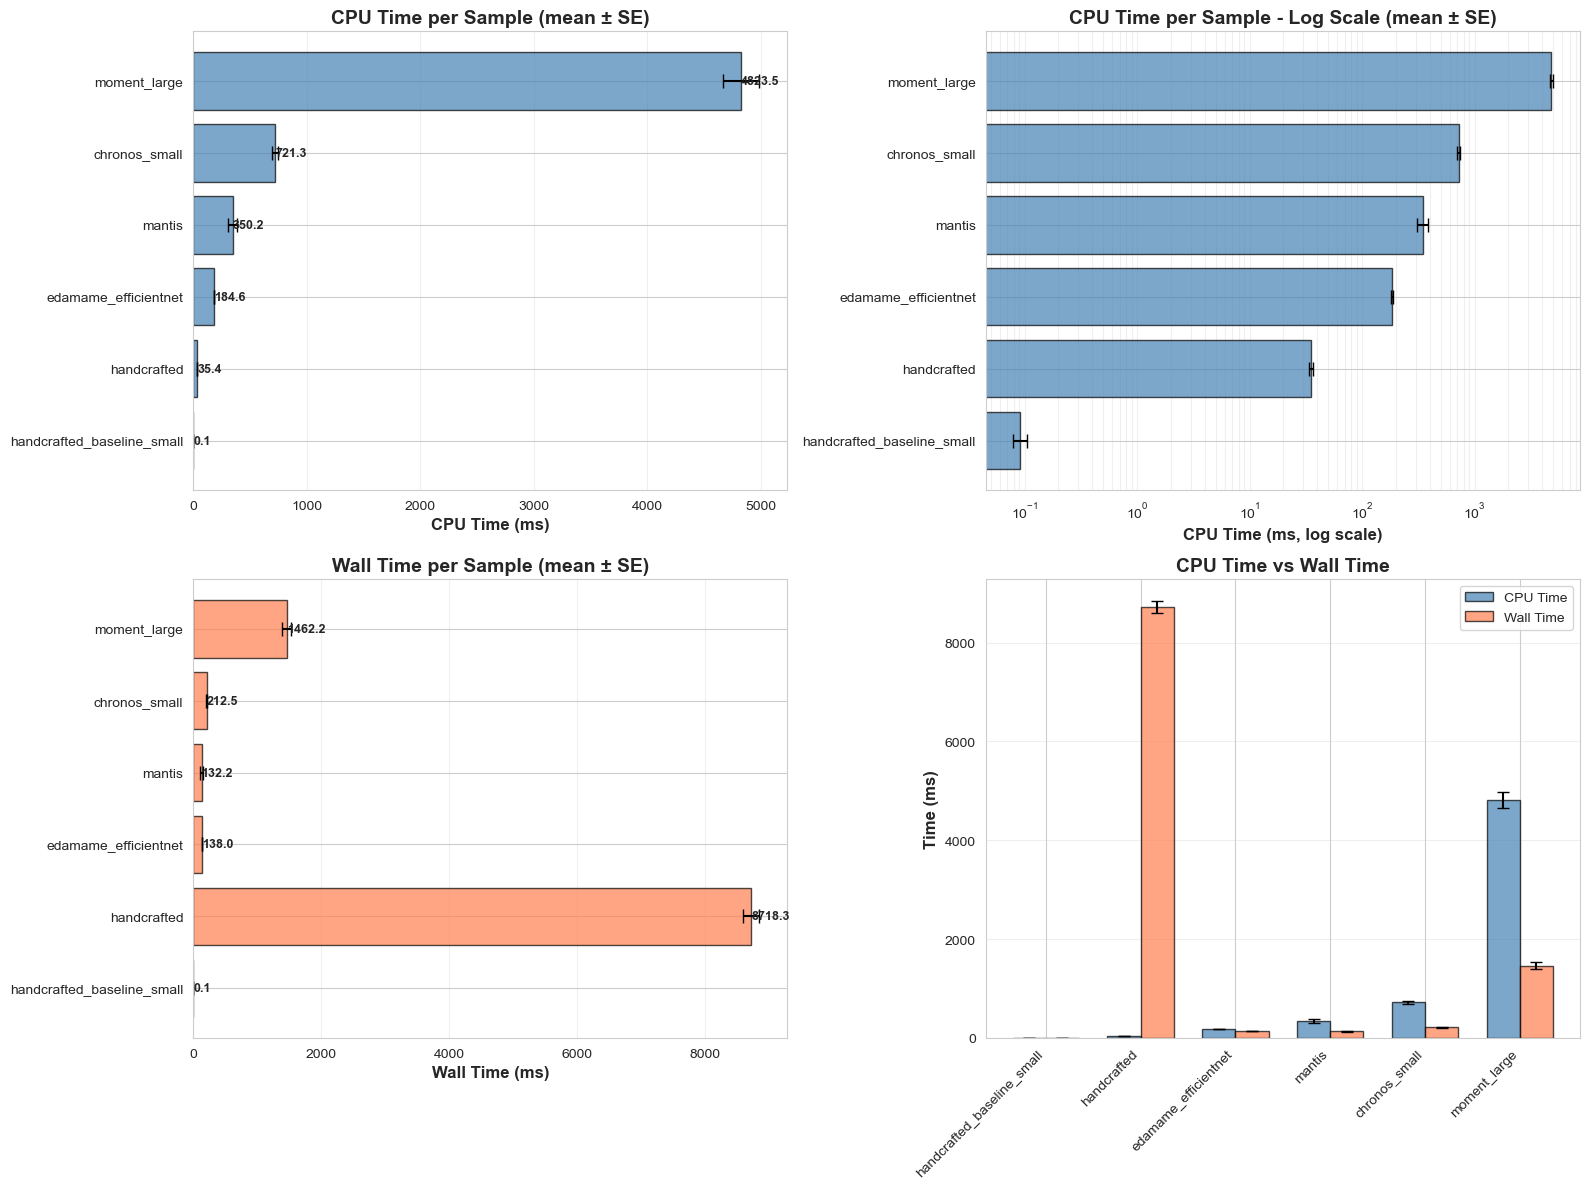

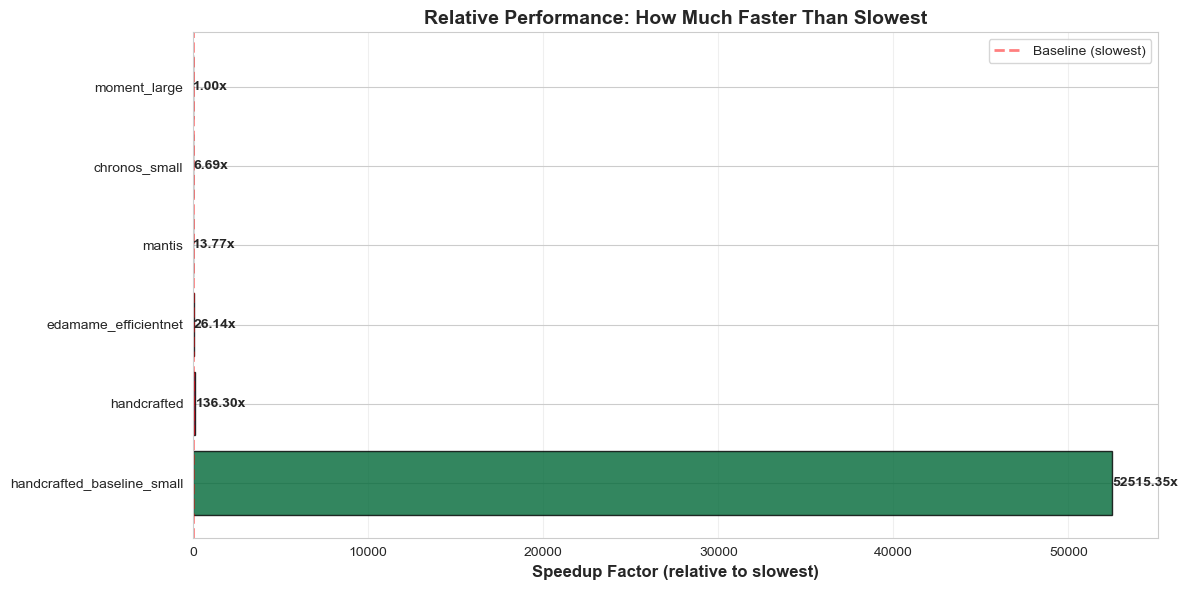


PERFORMANCE COMPARISON

Fastest: handcrafted_baseline_small
  CPU Time: 0.09 ± 0.01 ms

Slowest: moment_large
  CPU Time: 4823.53 ± 161.11 ms

Speedup (fastest vs slowest): 52515.35x



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

# Filter successful results and sort by CPU time
df_plot = df_numeric[df_numeric['status'] == 'SUCCESS'].copy()
df_plot = df_plot.sort_values('cpu_mean_ms')

if len(df_plot) > 0:
    # Create figure with subplots
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. CPU Time Comparison (Linear Scale)
    ax1 = axes[0, 0]
    bars1 = ax1.barh(df_plot['extractor'], df_plot['cpu_mean_ms'], 
                     xerr=df_plot['cpu_se_ms'], capsize=5, 
                     color='steelblue', alpha=0.7, edgecolor='black')
    ax1.set_xlabel('CPU Time (ms)', fontsize=12, fontweight='bold')
    ax1.set_title('CPU Time per Sample (mean ± SE)', fontsize=14, fontweight='bold')
    ax1.grid(axis='x', alpha=0.3)
    
    # Add value labels
    for i, (bar, val) in enumerate(zip(bars1, df_plot['cpu_mean_ms'])):
        ax1.text(val, bar.get_y() + bar.get_height()/2, 
                f'{val:.1f}', 
                ha='left', va='center', fontsize=9, fontweight='bold')
    
    # 2. CPU Time Comparison (Log Scale)
    ax2 = axes[0, 1]
    bars2 = ax2.barh(df_plot['extractor'], df_plot['cpu_mean_ms'], 
                     xerr=df_plot['cpu_se_ms'], capsize=5, 
                     color='steelblue', alpha=0.7, edgecolor='black')
    ax2.set_xscale('log')
    ax2.set_xlabel('CPU Time (ms, log scale)', fontsize=12, fontweight='bold')
    ax2.set_title('CPU Time per Sample - Log Scale (mean ± SE)', fontsize=14, fontweight='bold')
    ax2.grid(axis='x', alpha=0.3, which='both')
    
    # 3. Wall Time Comparison
    ax3 = axes[1, 0]
    bars3 = ax3.barh(df_plot['extractor'], df_plot['wall_mean_ms'], 
                     xerr=df_plot['wall_se_ms'], capsize=5, 
                     color='coral', alpha=0.7, edgecolor='black')
    ax3.set_xlabel('Wall Time (ms)', fontsize=12, fontweight='bold')
    ax3.set_title('Wall Time per Sample (mean ± SE)', fontsize=14, fontweight='bold')
    ax3.grid(axis='x', alpha=0.3)
    
    # Add value labels
    for i, (bar, val) in enumerate(zip(bars3, df_plot['wall_mean_ms'])):
        ax3.text(val, bar.get_y() + bar.get_height()/2, 
                f'{val:.1f}', 
                ha='left', va='center', fontsize=9, fontweight='bold')
    
    # 4. CPU vs Wall Time Comparison
    ax4 = axes[1, 1]
    x = range(len(df_plot))
    width = 0.35
    
    bars_cpu = ax4.bar([i - width/2 for i in x], df_plot['cpu_mean_ms'], 
                       width, yerr=df_plot['cpu_se_ms'], capsize=4,
                       label='CPU Time', color='steelblue', alpha=0.7, edgecolor='black')
    bars_wall = ax4.bar([i + width/2 for i in x], df_plot['wall_mean_ms'], 
                        width, yerr=df_plot['wall_se_ms'], capsize=4,
                        label='Wall Time', color='coral', alpha=0.7, edgecolor='black')
    
    ax4.set_ylabel('Time (ms)', fontsize=12, fontweight='bold')
    ax4.set_title('CPU Time vs Wall Time', fontsize=14, fontweight='bold')
    ax4.set_xticks(x)
    ax4.set_xticklabels(df_plot['extractor'], rotation=45, ha='right')
    ax4.legend(fontsize=10)
    ax4.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # ============================================================================
    # Additional Analysis: Speed Comparison
    # ============================================================================
    
    # Calculate speedup relative to slowest
    slowest = df_plot['cpu_mean_ms'].max()
    df_plot['speedup'] = slowest / df_plot['cpu_mean_ms']
    
    # Create speedup visualization
    fig2, ax = plt.subplots(1, 1, figsize=(12, 6))
    
    colors = plt.cm.RdYlGn(df_plot['speedup'] / df_plot['speedup'].max())
    bars = ax.barh(df_plot['extractor'], df_plot['speedup'], 
                   color=colors, alpha=0.8, edgecolor='black')
    
    ax.set_xlabel('Speedup Factor (relative to slowest)', fontsize=12, fontweight='bold')
    ax.set_title('Relative Performance: How Much Faster Than Slowest', 
                 fontsize=14, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    ax.axvline(x=1, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Baseline (slowest)')
    
    # Add value labels
    for bar, val in zip(bars, df_plot['speedup']):
        ax.text(val, bar.get_y() + bar.get_height()/2, 
                f'{val:.2f}x', 
                ha='left', va='center', fontsize=10, fontweight='bold')
    
    ax.legend()
    plt.tight_layout()
    plt.show()
    
    # Print comparison table
    print("\n" + "="*80)
    print("PERFORMANCE COMPARISON")
    print("="*80)
    print(f"\nFastest: {df_plot.iloc[0]['extractor']}")
    print(f"  CPU Time: {df_plot.iloc[0]['cpu_mean_ms']:.2f} ± {df_plot.iloc[0]['cpu_se_ms']:.2f} ms")
    print(f"\nSlowest: {df_plot.iloc[-1]['extractor']}")
    print(f"  CPU Time: {df_plot.iloc[-1]['cpu_mean_ms']:.2f} ± {df_plot.iloc[-1]['cpu_se_ms']:.2f} ms")
    print(f"\nSpeedup (fastest vs slowest): {df_plot.iloc[-1]['cpu_mean_ms'] / df_plot.iloc[0]['cpu_mean_ms']:.2f}x")
    print("\n" + "="*80)
    
else:
    print("No successful results to plot.")

In [5]:
import pandas as pd

df_numeric = pd.read_csv("../outputs/computational_complexity_benchmark.csv")
display(df_numeric)

,extractor,status,feature_size,cpu_mean_ms,cpu_se_ms,cpu_std_ms,wall_mean_ms,wall_se_ms,wall_std_ms,n_samples
0,chronos_small,SUCCESS,1536,636.95430,5.382167,24.069783,143.974927,1.159444,5.185193,20
1,edamame_efficientnet,SUCCESS,64,239.15730,2.759480,12.340768,158.188608,1.974674,8.831009,20
2,handcrafted,SUCCESS,45,54.93515,0.531606,2.377412,15137.213096,60.685736,271.394864,20
3,handcrafted_baseline_small,SUCCESS,3,0.05010,0.005762,0.025768,0.048121,0.005652,0.025278,20
4,mantis,SUCCESS,768,130.12125,10.024567,44.831226,45.157004,1.922375,8.597123,20
5,moment_large,SUCCESS,3,2217.19945,49.832018,222.855561,493.253375,11.638921,52.050835,20


In [6]:
df_numeric = df_numeric[df_numeric['extractor'] != 'handcrafted_baseline_small']

✓ Plot saved to: ../figures/computational_complexity_cpu_time.pdf


/var/folders/rc/t3h_b88s3vbg5dcd4pnlgskr0000gp/T/ipykernel_99405/2801369019.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(correct_names[::-1])


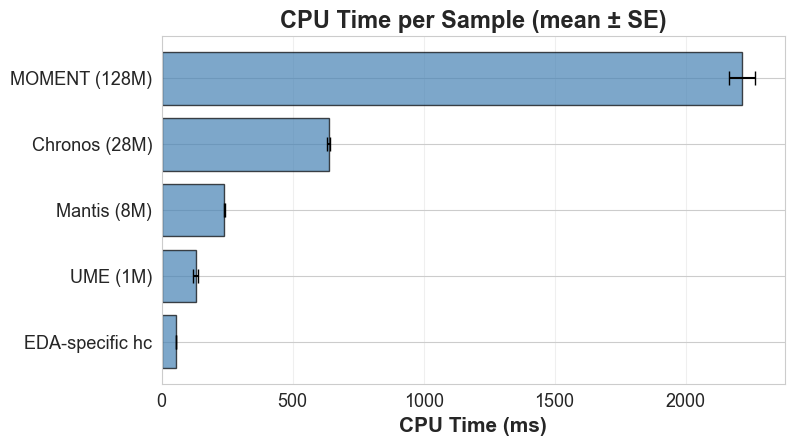

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

# Filter successful results and sort by CPU time
df_plot = df_numeric[df_numeric['status'] == 'SUCCESS'].copy()
df_plot = df_plot.sort_values('cpu_mean_ms')

correct_names = ['MOMENT (128M)', "Chronos (28M)", "Mantis (8M)", "UME (1M)", "EDA-specific hc"]

if len(df_plot) > 0:
    # Create single figure with CPU Time (Log Scale)
    fig, ax = plt.subplots(1, 1, figsize=(8, 4.5))
    
    bars = ax.barh(df_plot['extractor'], df_plot['cpu_mean_ms'], 
                   xerr=df_plot['cpu_se_ms'], capsize=5, 
                   color='steelblue', alpha=0.7, edgecolor='black')
    # ax.set_xscale('log')
    ax.set_xlabel('CPU Time (ms)', fontsize=15, fontweight='bold')
    ax.set_title('CPU Time per Sample (mean ± SE)', fontsize=17, fontweight='bold')
    ax.grid(axis='x', alpha=0.3, which='both')
    
    plt.tight_layout()
    
    ax.set_yticklabels(correct_names[::-1])
    ax.tick_params(axis='both', labelsize=13)
    
    # Save to PDF
    output_pdf = Path("../figures/computational_complexity_cpu_time.pdf")
    output_pdf.parent.mkdir(exist_ok=True)
    plt.savefig(output_pdf, format='pdf', bbox_inches='tight', dpi=300)
    print(f"✓ Plot saved to: {output_pdf}")
    
    plt.show()
    
else:
    print("No successful results to plot.")

In [ ]:
{"chronos_small": }
    

{'chronos_small': <edamame_downstream.feature_extraction.chronos.ChronosExtractor at 0x3342ccfe0>,
 'edamame_efficientnet': <edamame_downstream.feature_extraction.edamame.EdamameExtractor at 0x334a7a270>,
 'handcrafted': <edamame_downstream.feature_extraction.handcrafted.HandcraftedFeatureExtractor at 0x334a6caa0>,
 'handcrafted_baseline_small': <edamame_downstream.feature_extraction.handcrafted_baseline_small.HandcraftedFeatureExtractor at 0x334b4b950>,
 'mantis': <edamame_downstream.feature_extraction.mantis.MantisExtractor at 0x334eba420>,
 'moment_large': <edamame_downstream.feature_extraction.moment.MOMENTExtractor at 0x334f50500>}

In [ ]:
# Install fvcore for FLOPs computation (if not already installed)
# !pip install fvcore

In [8]:
import torch
import torch.nn as nn
from fvcore.nn import FlopCountAnalysis, flop_count_table
import warnings

warnings.filterwarnings('ignore')

# ============================================================================
# COMPUTE GFLOPs FOR DEEP LEARNING FEATURE EXTRACTORS
# ============================================================================

def compute_gflops(model, input_shape=(1, 3, 240)):
    """
    Compute GFLOPs for a PyTorch model.
    
    Args:
        model: PyTorch model
        input_shape: Input tensor shape (batch_size, channels, sequence_length)
                     Default: (1, 3, 240) = 1 batch, 3 channels, 240 sequence length
    
    Returns:
        gflops: Floating point operations in billions (GFLOPs)
    """
    try:
        # Create dummy input
        dummy_input = torch.randn(input_shape)
        
        # Move model to CPU for consistent measurement
        model = model.cpu()
        model.eval()
        
        # Compute FLOPs using fvcore
        flops = FlopCountAnalysis(model, dummy_input)
        total_flops = flops.total()
        
        # Convert to GFLOPs (billions of FLOPs)
        gflops = total_flops / 1e9
        
        return gflops
    except Exception as e:
        print(f"Error computing FLOPs: {e}")
        return None


def compute_gflops_chronos(extractor):
    """
    Special handler for Chronos models which use a pipeline with tokenization.
    
    Args:
        extractor: ChronosExtractor instance
    
    Returns:
        gflops: Floating point operations in billions (GFLOPs)
    """
    try:
        # Extract the inner transformer model from the pipeline
        # extractor.pipeline.model.model is the actual PreTrainedModel
        inner_model = extractor.pipeline.model.model
        
        # Get the encoder (for seq2seq models like T5-based Chronos)
        if hasattr(inner_model, 'encoder'):
            encoder = inner_model.encoder
        else:
            encoder = inner_model
        
        # Chronos expects tokenized inputs (token IDs), not raw time series
        # Context length from config (typically 512 for chronos-t5-small)
        context_length = extractor.pipeline.tokenizer.config.context_length
        
        # Create dummy token IDs input (batch_size=1, seq_length=context_length)
        dummy_input_ids = torch.randint(0, 4096, (1, context_length), dtype=torch.long)
        dummy_attention_mask = torch.ones((1, context_length), dtype=torch.long)
        
        # Move to CPU
        encoder = encoder.cpu()
        encoder.eval()
        
        # Compute FLOPs for the encoder
        # For transformer models, we need to pass both input_ids and attention_mask
        flops = FlopCountAnalysis(encoder, (dummy_input_ids, dummy_attention_mask))
        total_flops = flops.total()
        
        # Convert to GFLOPs
        gflops = total_flops / 1e9
        
        return gflops
    except Exception as e:
        print(f"Error computing FLOPs for Chronos: {e}")
        import traceback
        traceback.print_exc()
        return None


def compute_gflops_edamame(extractor):
    """
    Special handler for EDAMAME models which use a pipeline.
    
    Args:
        extractor: EdamameExtractor instance
    
    Returns:
        gflops: Floating point operations in billions (GFLOPs)
    """
    try:
        # Extract the inner model from the pipeline
        # extractor.pipeline.model is the actual EfficientNetContrastive model
        if hasattr(extractor.pipeline, 'model'):
            model = extractor.pipeline.model
        else:
            raise AttributeError("Could not find model in EdamamePipeline")
        
        # EDAMAME's forward method expects two views (x_1, x_2) for contrastive learning
        # We need to use forward_single for inference on a single view
        # Input shape: (batch=1, seq_length=240, channels=3) before permutation
        # The model internally permutes it to (batch, channels, seq_length)
        dummy_input = torch.randn(1, 240, 3)
        
        # Move to CPU
        model = model.cpu()
        model.eval()
        
        # Use forward_single method instead of forward
        # We need to wrap it in a lambda to match FlopCountAnalysis expectations
        def forward_wrapper(x):
            return model.forward_single(x)
        
        # Compute FLOPs using the forward_single method
        original_forward = model.forward
        model.forward = forward_wrapper
        flops = FlopCountAnalysis(model, dummy_input)
        total_flops = flops.total()
        model.forward = original_forward  # Restore original forward
        
        # Convert to GFLOPs
        gflops = total_flops / 1e9
        
        return gflops
    except Exception as e:
        print(f"Error computing FLOPs for EDAMAME: {e}")
        import traceback
        traceback.print_exc()
        return None


class MomentEmbeddingWrapper(nn.Module):
    def __init__(self, pipeline):
        super().__init__()
        self.pipeline = pipeline

    def forward(self, x):
        return self.pipeline(x_enc=x).embeddings


def compute_gflops_moment(extractor):
    """
    Special handler for MOMENT models, whose pipeline uses a keyword-only
    ``x_enc`` argument and returns embeddings via a structured output object.

    Args:
        extractor: MOMENTExtractor instance
    
    Returns:
        gflops: Floating point operations in billions (GFLOPs)
    """
    try:
        if not hasattr(extractor, 'pipeline'):
            raise AttributeError("Could not find pipeline in MOMENTExtractor")

        pipeline = extractor.pipeline.cpu().eval()
        wrapper = MomentEmbeddingWrapper(pipeline)

        # MOMENTExtractor permutes inputs to (batch, channels, time) before calling the pipeline.
        dummy_input = torch.randn(1, 3, 240)

        total_flops = FlopCountAnalysis(wrapper, dummy_input).total()
        return total_flops / 1e9
    except Exception as e:
        print(f"Error computing FLOPs for MOMENT: {e}")
        import traceback
        traceback.print_exc()
        return None


def compute_gflops_mantis(extractor, n_channels=3):
    """
    Special handler for Mantis models which use a MantisTrainer pipeline.

    Mantis processes multichannel inputs one channel at a time inside
    ``MantisTrainer.transform``. The underlying backbone therefore expects a
    single-channel tensor with the model's native sequence length.

    Args:
        extractor: MantisExtractor instance
        n_channels: Number of input channels processed per sample
    
    Returns:
        gflops: Floating point operations in billions (GFLOPs)
    """
    try:
        if hasattr(extractor, 'network'):
            network = extractor.network
        elif hasattr(extractor.pipeline, 'network'):
            network = extractor.pipeline.network
        else:
            raise AttributeError("Could not find network in MantisExtractor or MantisTrainer")

        seq_len = getattr(network, 'seq_len', 512)

        # Mantis8M consumes one channel at a time with shape (batch, 1, seq_len).
        dummy_input = torch.randn(1, 1, seq_len)

        network = network.cpu()
        network.eval()

        per_channel_flops = FlopCountAnalysis(network, dummy_input).total()
        total_flops = per_channel_flops * n_channels

        return total_flops / 1e9
    except Exception as e:
        print(f"Error computing FLOPs for Mantis: {e}")
        import traceback
        traceback.print_exc()
        return None


# Dictionary to store GFLOPs results
gflops_results = {}

print("="*80)
print("COMPUTING GFLOPs FOR FEATURE EXTRACTORS")
print("="*80)
print()

# Iterate through feature extractors (excluding handcrafted)
for name, extractor in feature_extractors.items():
    if extractor is None:
        print(f"✗ {name}: Not loaded")
        continue
    
    # Skip handcrafted features
    if "handcrafted" in name.lower():
        print(f"⊘ {name}: Skipped (handcrafted features)")
        gflops_results[name] = None
        continue
    
    print(f"Computing GFLOPs for: {name}")
    
    try:
        # Special handling for Chronos
        if "chronos" in name.lower():
            print(f"  Using special Chronos handler...")
            gflops = compute_gflops_chronos(extractor)
        # Special handling for EDAMAME
        elif "edamame" in name.lower():
            print(f"  Using special EDAMAME handler (with forward_single)...")
            gflops = compute_gflops_edamame(extractor)
        # Special handling for MOMENT
        elif "moment" in name.lower():
            print(f"  Using special MOMENT handler...")
            gflops = compute_gflops_moment(extractor)
        # Special handling for Mantis
        elif "mantis" in name.lower():
            print(f"  Using special Mantis handler...")
            gflops = compute_gflops_mantis(extractor)
        else:
            # Try to extract the actual model from the feature extractor
            # Different feature extractors might have different structures
            if hasattr(extractor, 'model'):
                model = extractor.model
            elif hasattr(extractor, 'encoder'):
                model = extractor.encoder
            elif hasattr(extractor, 'net'):
                model = extractor.net
            elif hasattr(extractor, 'backbone'):
                model = extractor.backbone
            else:
                # Assume the extractor itself is the model
                model = extractor
            
            # Compute GFLOPs
            # Input shape: (batch=1, channels=3, sequence_length=240)
            # 240 values with 3 channels
            gflops = compute_gflops(model, input_shape=(1, 3, 240))
        
        if gflops is not None:
            gflops_results[name] = gflops
            print(f"  ✓ GFLOPs: {gflops:.4f}")
        else:
            gflops_results[name] = None
            print(f"  ✗ Failed to compute GFLOPs")
            
    except Exception as e:
        print(f"  ✗ Error: {e}")
        import traceback
        traceback.print_exc()
        gflops_results[name] = None
    
    print()

print("="*80)
print("GFLOPs COMPUTATION COMPLETE")
print("="*80)

COMPUTING GFLOPs FOR FEATURE EXTRACTORS

Computing GFLOPs for: chronos_small
  Using special Chronos handler...


  ✓ GFLOPs: 11.2743

Computing GFLOPs for: edamame_efficientnet
  Using special EDAMAME handler (with forward_single)...


  ✓ GFLOPs: 0.0355

⊘ handcrafted: Skipped (handcrafted features)
⊘ handcrafted_baseline_small: Skipped (handcrafted features)
Computing GFLOPs for: mantis
  Using special Mantis handler...


prj, prj.0, prj.1


  ✓ GFLOPs: 0.8521

Computing GFLOPs for: moment_large
  Using special MOMENT handler...


pipeline.encoder.embed_tokens


  ✓ GFLOPs: 27.8788

GFLOPs COMPUTATION COMPLETE


In [9]:
# Display GFLOPs results
print("\nGFLOPs Summary:")
print("-" * 60)
for name, gflops in gflops_results.items():
    if gflops is not None:
        print(f"{name:40s}: {gflops:8.4f} GFLOPs")
    else:
        print(f"{name:40s}: N/A")
print("-" * 60)


GFLOPs Summary:
------------------------------------------------------------
chronos_small                           :  11.2743 GFLOPs
edamame_efficientnet                    :   0.0355 GFLOPs
handcrafted                             : N/A
handcrafted_baseline_small              : N/A
mantis                                  :   0.8521 GFLOPs
moment_large                            :  27.8788 GFLOPs
------------------------------------------------------------


✓ Plot saved to: ../figures/computational_complexity_gflops.pdf


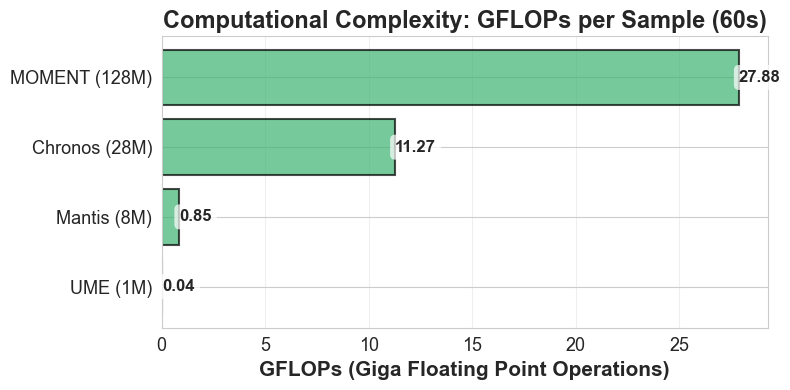


GFLOPs SUMMARY

Lowest GFLOPs: UME (1M)
  → 0.0355 GFLOPs

Highest GFLOPs: MOMENT (128M)
  → 27.8788 GFLOPs

Ratio (Highest/Lowest): 784.70x


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

# ============================================================================
# PLOT GFLOPs FOR DEEP LEARNING MODELS
# ============================================================================

# Filter out None values and handcrafted features
gflops_data = {k: v for k, v in gflops_results.items() if v is not None}

if len(gflops_data) > 0:
    # Create DataFrame for plotting
    df_gflops = pd.DataFrame(list(gflops_data.items()), columns=['Extractor', 'GFLOPs'])
    df_gflops = df_gflops.sort_values('GFLOPs', ascending=True)
    
    # Map to correct names
    name_mapping = {
        'chronos_small': 'Chronos (28M)',
        'edamame_efficientnet': 'UME (1M)',
        'mantis': 'Mantis (8M)',
        'moment_large': 'MOMENT (128M)'
    }
    
    df_gflops['Display_Name'] = df_gflops['Extractor'].map(name_mapping)
    
    # Create square figure
    fig, ax = plt.subplots(1, 1, figsize=(8, 4))
    
    # Create bar plot
    bars = ax.barh(df_gflops['Display_Name'], df_gflops['GFLOPs'], 
                   color='mediumseagreen', alpha=0.7, edgecolor='black', linewidth=1.5)
    
    ax.set_xlabel('GFLOPs (Giga Floating Point Operations)', fontsize=15, fontweight='bold')
    ax.set_title('Computational Complexity: GFLOPs per Sample (60s)', fontsize=17, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    ax.tick_params(axis='both', labelsize=13)
    
    # Add value labels on bars
    for bar, val in zip(bars, df_gflops['GFLOPs']):
        ax.text(val, bar.get_y() + bar.get_height()/2, 
                f'{val:.2f}', 
                ha='left', va='center', fontsize=12, fontweight='bold', 
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='none', alpha=0.7))
    
    plt.tight_layout()
    
    # Save to PDF
    output_pdf = Path("../figures/computational_complexity_gflops.pdf")
    output_pdf.parent.mkdir(exist_ok=True)
    plt.savefig(output_pdf, format='pdf', bbox_inches='tight', dpi=300)
    print(f"✓ Plot saved to: {output_pdf}")
    
    plt.show()
    
    # Print summary statistics
    print("\n" + "="*80)
    print("GFLOPs SUMMARY")
    print("="*80)
    print(f"\nLowest GFLOPs: {df_gflops.iloc[0]['Display_Name']}")
    print(f"  → {df_gflops.iloc[0]['GFLOPs']:.4f} GFLOPs")
    print(f"\nHighest GFLOPs: {df_gflops.iloc[-1]['Display_Name']}")
    print(f"  → {df_gflops.iloc[-1]['GFLOPs']:.4f} GFLOPs")
    print(f"\nRatio (Highest/Lowest): {df_gflops.iloc[-1]['GFLOPs'] / df_gflops.iloc[0]['GFLOPs']:.2f}x")
    print("="*80)
    
else:
    print("No GFLOPs data available to plot.")

In [15]:
# Save GFLOPs results to CSV
df_gflops_save = pd.DataFrame(list(gflops_results.items()), columns=['extractor', 'gflops'])
output_path_gflops = Path("../outputs/computational_complexity_gflops.csv")
df_gflops_save.to_csv(output_path_gflops, index=False)
print(f"✓ GFLOPs results saved to: {output_path_gflops}")

✓ GFLOPs results saved to: ../outputs/computational_complexity_gflops.csv
